1.2: Sobreajuste, subajuste y validación cruzada


**Objetivo:** Comparar modelos simples y complejos, e introducir validación cruzada.  
**Dataset:** `rendimiento_estudiantil.csv`
Usar en **Google Colab** o en Jupyter.

## Actividades de la sesión

1. Cargar y revisar el dataset.  
2. Preparar variables de entrada y salida.  
3. Entrenar el modelo.  
4. Evaluar resultados.  
5. Interpretar lo que ocurrió.  
6. Interpretación.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [15]:
from pathlib import Path
import pandas as pd

def cargar_csv(nombre_archivo):
    rutas = [
        Path(nombre_archivo),
        Path("../datasets") / nombre_archivo,
        Path("datasets") / nombre_archivo,
        Path("/content") / nombre_archivo,
        Path("/content/datasets") / nombre_archivo,
    ]
    for ruta in rutas:
        if ruta.exists():
            print(f"Archivo encontrado en: {ruta}")
            return pd.read_csv(ruta)
    raise FileNotFoundError(
        f"No se encontró {nombre_archivo}. Súbelo a Colab o colócalo en la carpeta datasets."
    )


In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [17]:
# Cargamos solo las dos columnas que usaremos:
# - horas_estudio: variable de entrada (X)
# - promedio_final: variable que queremos predecir (y)
df = cargar_csv("rendimiento_estudiantil.csv")
df = df[["horas_estudio", "promedio_final"]].copy()
df.head()


Archivo encontrado en: rendimiento_estudiantil.csv


,horas_estudio,promedio_final
0,9.9,100.0
1,5.9,96.7
2,11.3,100.0
3,11.8,100.0
4,3.1,94.0


## Objetivo

Para visualizar mejor el sobreajuste, se utilizará una sola variable:
`horas_estudio`.

Probaremos modelos polinómicos con diferentes grados.


In [18]:
# X = variable de entrada (cuánto estudió el alumno)
# y = variable de salida (qué calificación sacó)
X = df[["horas_estudio"]]
y = df["promedio_final"]


# Dividimos: 75% para entrenar el modelo, 25% para probarlo
# random_state=42 garantiza que siempre obtengamos la misma división

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [19]:
resultados = []

# Probamos 3 modelos: uno muy simple (grado 1), uno intermedio (grado 2)
# y uno muy complejo (grado 8)
for grado in [1, 2, 8]:
  # Pipeline: primero transforma X a polinomio, luego aplica regresión lineal
    modelo = Pipeline([
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("reg", LinearRegression())
    ])
    modelo.fit(X_train, y_train)  # Entrenamos con los datos de entrenamiento

    pred_train = modelo.predict(X_train) # Predice sobre train
    pred_test = modelo.predict(X_test) # Predice sobre test (datos nuevos)

    # Validación cruzada con 5 pliegues: divide los datos en 5 partes,
    # entrena en 4 y prueba en 1, rotando. Nos da una estimación más confiable.

    cv_scores = cross_val_score(
        modelo, X, y, cv=5, scoring="neg_root_mean_squared_error"
    )

    resultados.append({
        "grado": grado,
        "R2_train": r2_score(y_train, pred_train), # Qué tan bien aprende
        "R2_test": r2_score(y_test, pred_test), # Qué tan bien generaliza
        "RMSE_cv_promedio": -cv_scores.mean()  # Error promedio en CV
    })

# Tabla de resultados
resultados_df = pd.DataFrame(resultados).round(4)
resultados_df


,grado,R2_train,R2_test,RMSE_cv_promedio
0,1,0.2209,0.1268,3.4205
1,2,0.2526,0.1195,3.3614
2,8,0.2789,0.0720,3.5319


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


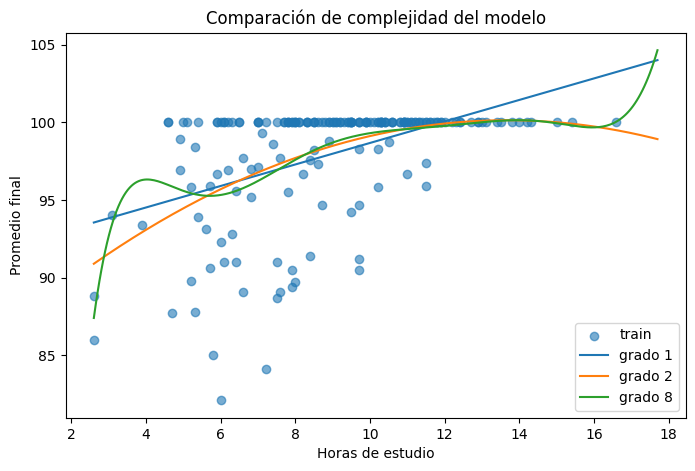

In [20]:
# Graficamos las curvas de cada modelo sobre los puntos de entrenamiento
x_linea = np.linspace(X["horas_estudio"].min(), X["horas_estudio"].max(), 300).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label="train")

for grado in [1, 2, 8]:
    modelo = Pipeline([
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("reg", LinearRegression())
    ])
    modelo.fit(X_train, y_train)
    y_linea = modelo.predict(x_linea)
    plt.plot(x_linea, y_linea, label=f"grado {grado}")

plt.xlabel("Horas de estudio")
plt.ylabel("Promedio final")
plt.title("Comparación de complejidad del modelo")
plt.legend()
plt.show()


## Interpretación

- Un modelo **muy simple** puede no capturar el patrón.
- Un modelo **muy complejo** puede ajustarse demasiado a entrenamiento.
- La **validación cruzada** ayuda a estimar qué tan estable es el modelo.


## Actividad:

1. Cambia los grados por `1, 3 y 12`.  
2. Repite el experimento.  
3. Anota cuál parece estar subajustado, cuál sobreajustado y cuál equilibrado.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


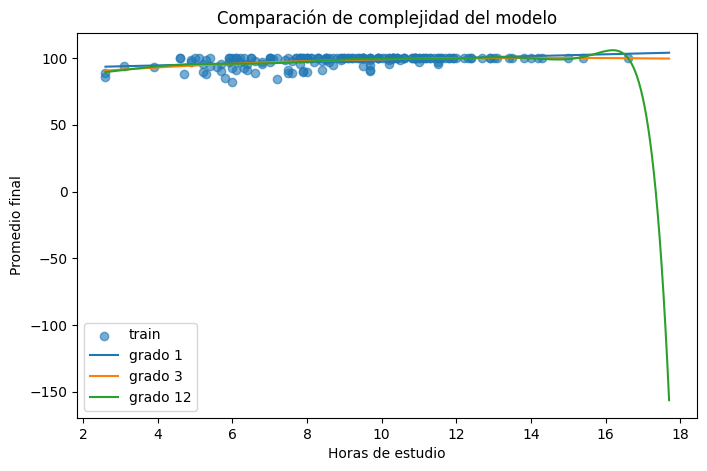

In [22]:
# Escribe aquí tu comparación adicional

# ACTIVIDAD: Cambiamos los grados a 1, 3 y 12
# Definimos un rango uniforme de valores en X para graficar curvas suaves
x_linea = np.linspace(X["horas_estudio"].min(), X["horas_estudio"].max(), 300).reshape(-1, 1)

plt.figure(figsize=(8, 5))

# Mostramos los datos de entrenamiento como puntos de referencia
plt.scatter(X_train, y_train, alpha=0.6, label="train")

# Probamos tres niveles de complejidad para ver cómo ajusta cada uno
for grado in [1, 3, 12]:

    # Creamos un pipeline que primero transforma las features a polinomial
    # y luego entrena una regresión lineal sobre esas features
    modelo = Pipeline([
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("reg", LinearRegression())
    ])

    modelo.fit(X_train, y_train)

    # Predecimos sobre el rango continuo para obtener una curva sin saltos
    y_linea = modelo.predict(x_linea)
    plt.plot(x_linea, y_linea, label=f"grado {grado}")

# Etiquetas y título para que la gráfica sea autoexplicativa
plt.xlabel("Horas de estudio")
plt.ylabel("Promedio final")
plt.title("Comparación de complejidad del modelo")
plt.legend()
plt.show()


- Grado 1  → SUBAJUSTADO: R2 bajo tanto en train como en test
- Grado 3  → EQUILIBRADO: R2 similar en ambos, RMSE_cv más bajo
- Grado 12 → SOBREAJUSTADO: R2 muy alto en train pero cae en test

## Conclusión
Redacta una conclusión breve respondiendo:
¿por qué no siempre el modelo más complejo es el mejor?

Un modelo más complejo no siempre es el mejor. A veces aprende demasiado bien los datos con los que entrena, incluyendo el ruido y las excepciones, y cuando le llegan datos nuevos, falla.
En este experimento lo vimos así:

El grado 1 fue demasiado básico, como trazar una línea recta en algo que claramente tiene curva. No alcanzó a aprender el patrón.
El grado 3 fue el justo: aprendió lo suficiente sin pasarse, y funcionó bien también con datos que no había visto.
El grado 12 se pasó de listo. Memorizó cada punto del entrenamiento pero cuando le llegaron datos nuevos, ya no supo qué hacer.

Por eso usamos validación cruzada: en lugar de confiar solo en cómo le fue con los datos que ya conoce, lo probamos con datos distintos varias veces. Así sabemos si el modelo de verdad aprendió, o solo memorizó.